In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

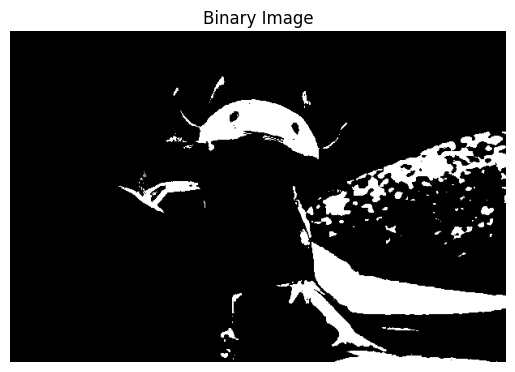

In [4]:
image_path = '../../input.jpg'
image_color = cv2.imread(image_path)
image = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title('Binary Image')
plt.axis('off')
plt.show()

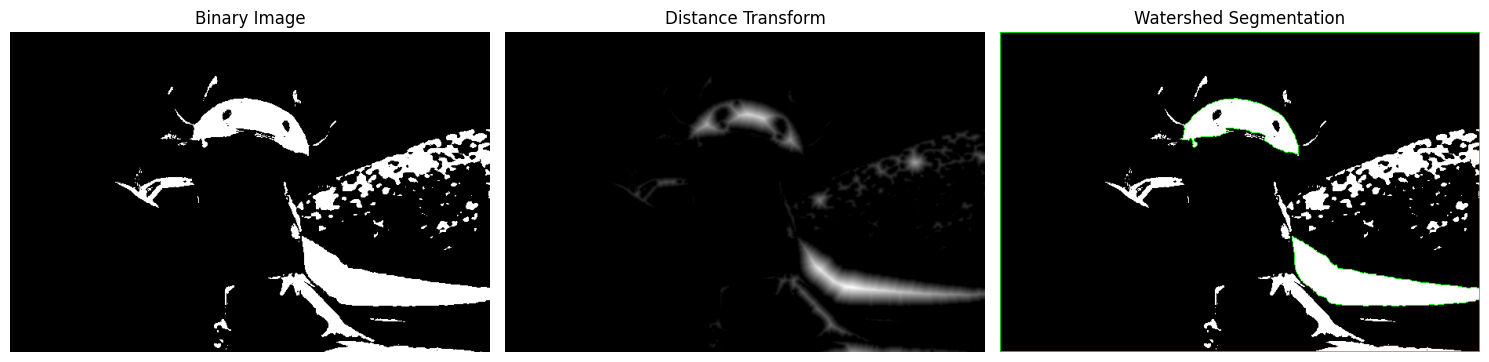

In [5]:
sure_bg = cv2.dilate(binary, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=3)

dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR), markers)

watershed_result = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
watershed_result[markers == -1] = [0, 255, 0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dist_transform, cmap='gray')
plt.title('Distance Transform')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(watershed_result, cv2.COLOR_BGR2RGB))
plt.title('Watershed Segmentation')
plt.axis('off')

plt.tight_layout()
plt.show()

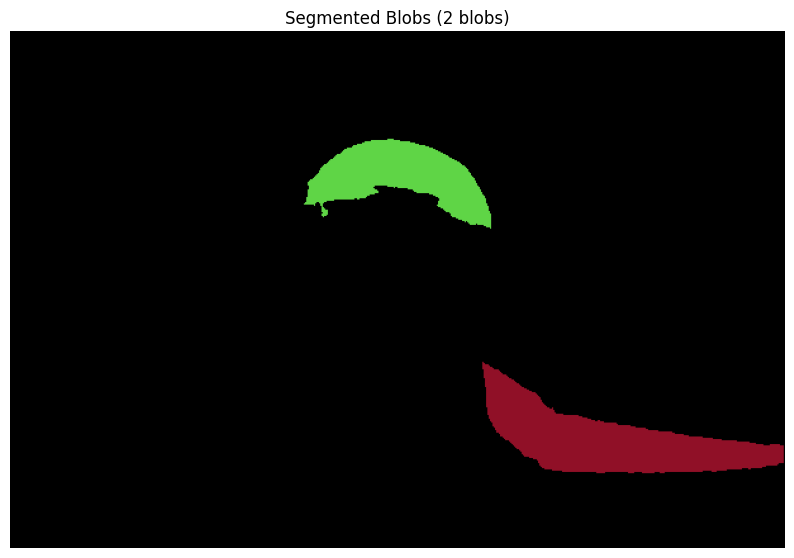

In [6]:
num_blobs = len(np.unique(markers)) - 2

colored_segments = np.zeros((binary.shape[0], binary.shape[1], 3), dtype=np.uint8)
colors = np.random.randint(0, 255, (num_blobs + 2, 3))

for i in range(binary.shape[0]):
    for j in range(binary.shape[1]):
        if markers[i, j] > 1:
            colored_segments[i, j] = colors[markers[i, j]]

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(colored_segments, cv2.COLOR_BGR2RGB))
plt.title(f'Segmented Blobs ({num_blobs} blobs)')
plt.axis('off')
plt.show()